# 🔍 Phase 6 — Explainability: SHAP & Grad-CAM

This notebook adds **Explainable AI (XAI)** to the SHAR system:
- **Grad-CAM**: Visualize which spatial regions activated the CNN
- **SHAP**: Understand feature importance across time
- Class activation maps on suspicious activity samples

In [9]:
import sys, os
sys.path.insert(0, "../src")
import torch, cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

from utils import get_device, CLASS_NAMES, SUSPICIOUS_CLASSES
from dataset import extract_frames, get_transforms
from model import CNNLSTM

device = get_device()
cfg_frames = 20


✅ GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU | VRAM: 6.4 GB


In [10]:
import sys
import importlib
if 'model' in sys.modules:
    importlib.reload(sys.modules['model'])
from model import CNNLSTM
print("✅ Model module reloaded with latest fixes (float32 forced for LSTM).")

✅ Model module reloaded with latest fixes (float32 forced for LSTM).


In [11]:
# ── Load best model ──────────────────────────────────────
model = CNNLSTM(num_classes=21, hidden_size=256, num_layers=2).to(device)
ckpt_path = "../models/saved/cnn_lstm_best.pth"

if os.path.exists(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt.get("model_state_dict", ckpt))
    print(f"✅ Model loaded from {ckpt_path}")
    print(f"   Training epoch: {ckpt.get('epoch', 'N/A')} | Val Acc: {ckpt.get('val_acc', 'N/A'):.2f}%")
else:
    print("⚠️  No checkpoint found. Please train the model first (Notebook 03).")
model.eval();


✅ Model loaded from ../models/saved/cnn_lstm_best.pth
   Training epoch: 1 | Val Acc: 6.70%


C:\Users\Abhinav\AppData\Local\Temp\ipykernel_1376\3011560842.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        # Use hooks to capture internal state
        target_layer.register_full_backward_hook(self._save_gradients)
        target_layer.register_forward_hook(self._save_activations)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        # grad_output is a tuple; we want the gradient of the output
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, target_class=None):
        # Ensure input is float32
        input_tensor = input_tensor.to(torch.float32)
        
        # Must be in train mode for cudnn RNN backward pass
        self.model.train()
        
        # Disable autocast to maintain float32 precision for heatmaps
        with torch.amp.autocast(device_type='cuda', enabled=False):
            output = self.model(input_tensor)
            if target_class is None:
                target_class = output.argmax(1).item()
            
            self.model.zero_grad()
            score = output[0, target_class]
            score.backward()
            
        # Revert to evaluation mode
        self.model.eval()
            
        # Calculate Grad-CAM
        # self.gradients shape: [1, C, H, W]
        # self.activations shape: [1, C, H, W]
        grads = self.gradients.mean(dim=[0, 2, 3]) # GAP over batch and spatial
        act = self.activations[0]
        
        # Weighted sum of activations
        cam = (grads[:, None, None] * act).sum(0)
        
        # ReLU to keep only positive activations
        cam = torch.relu(cam)
        
        # Convert to numpy and normalize
        cam = cam.cpu().numpy()
        cam = cam - np.min(cam)
        if np.max(cam) > 0:
            cam = cam / np.max(cam)
            
        return cam.astype(np.float32), CLASS_NAMES[target_class]


In [13]:
# Hook into last conv layer of ResNet50 for Grad-CAM
target_layer = list(model.cnn.children())[-2][-1].conv3
grad_cam = GradCAM(model, target_layer)
print("✅ Grad-CAM initialized on last ResNet50 conv block.")

✅ Grad-CAM initialized on last ResNet50 conv block.


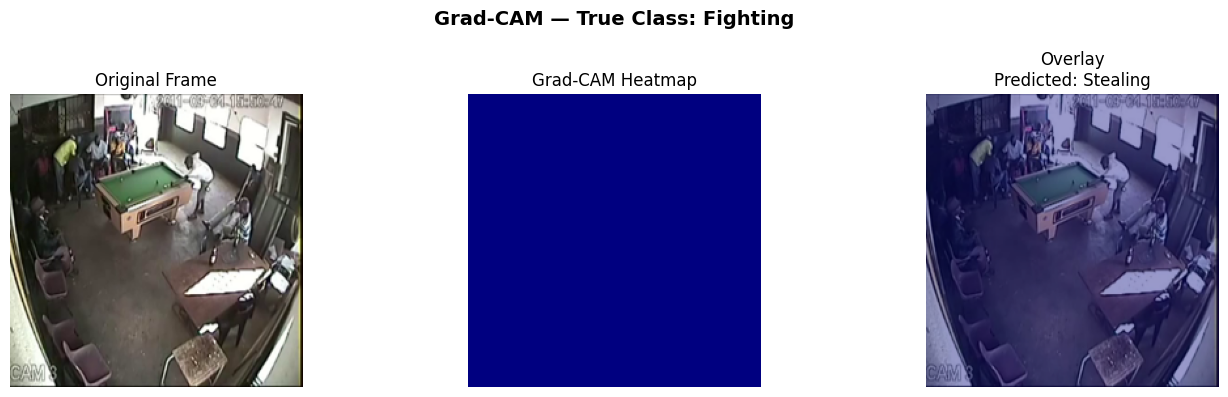

✅ Grad-CAM saved. Predicted: Stealing


In [14]:
# ── Apply Grad-CAM to a sample video ─────────────────────
DATA_ROOT = "../data/raw"
sample_class = "Fighting"
sample_videos = list((os.path.join(DATA_ROOT, "test", sample_class)).rstrip() and
                      __import__("pathlib").Path(DATA_ROOT, "test", sample_class).glob("*.mp4"))

if not sample_videos:
    sample_videos = list(__import__("pathlib").Path(DATA_ROOT, "val", sample_class).glob("*.mp4"))

if sample_videos:
    vid_path = str(sample_videos[0])
    frames = extract_frames(vid_path, num_frames=cfg_frames)
    transform = get_transforms("val")
    tensor = torch.stack([transform(f) for f in frames]).unsqueeze(0).to(device).float()

    cam_map, pred_class = grad_cam.generate(tensor)
    cam_resized = cv2.resize(cam_map, (224, 224))
    cam_heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    cam_heatmap = cv2.cvtColor(cam_heatmap, cv2.COLOR_BGR2RGB)

    # Display on middle frame
    mid_frame = frames[cfg_frames // 2]
    mid_frame_resized = cv2.resize(mid_frame, (224, 224))
    overlay = (0.6 * mid_frame_resized + 0.4 * cam_heatmap).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(mid_frame_resized); axes[0].set_title("Original Frame"); axes[0].axis("off")
    axes[1].imshow(cam_heatmap); axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")
    axes[2].imshow(overlay); axes[2].set_title(f"Overlay\nPredicted: {pred_class}"); axes[2].axis("off")
    plt.suptitle(f"Grad-CAM — True Class: {sample_class}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../results/plots/gradcam_visualization.png", dpi=150)
    plt.show()
    print(f"✅ Grad-CAM saved. Predicted: {pred_class}")
else:
    print("⚠️  Place test videos in data/raw/test/Fighting/ to run this cell.")


In [15]:
class AttentionExtractor(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model
        self._attn_weights = None

    def forward(self, x):
        B, T, C, H, W = x.shape
        x_flat = x.view(B * T, C, H, W)
        
        # We must use the same device as the input x
        device = x.device
        
        # Forward pass through CNN and LSTM
        feats = self.base.cnn(x_flat).squeeze(-1).squeeze(-1).view(B, T, -1)
        lstm_out, _ = self.base.lstm(feats)
        
        # Capture raw attention scores
        raw_attn = self.base.attention(lstm_out)  # (B, T, 1)
        
        # Calculate weights - KEEP on same device for context calculation
        weights = torch.softmax(raw_attn, dim=1)
        
        # Save a copy to CPU for plotting later
        self._attn_weights = weights.detach().cpu()
        
        # Calculate context on the correct device (GPU)
        context = (weights * lstm_out).sum(dim=1)
        
        return self.base.classifier(context)


🎬 Analyzing video: ..\data\raw\test\Fighting\Fighting019_x264.mp4


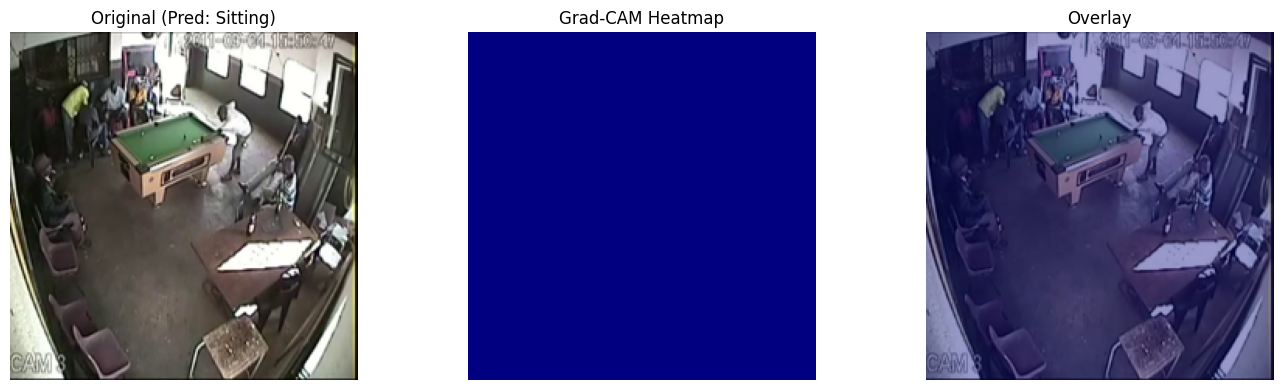

In [16]:
# ── Section 1.4: Apply Grad-CAM to a sample video ─────────────────────
DATA_ROOT = "../data/raw"
sample_class = "Fighting" # You can change this to "Normal", etc.
sample_videos = list(__import__("pathlib").Path(DATA_ROOT, "test", sample_class).glob("*.mp4"))

if not sample_videos:
    sample_videos = list(__import__("pathlib").Path(DATA_ROOT, "val", sample_class).glob("*.mp4"))

if sample_videos:
    vid_path = str(sample_videos[0])
    print(f"🎬 Analyzing video: {vid_path}")
    
    frames = extract_frames(vid_path, num_frames=cfg_frames)
    transform = get_transforms("val")
    # Force float32 to match model requirements
    tensor = torch.stack([transform(f) for f in frames]).unsqueeze(0).to(device).float()

    # Generate Heatmap
    cam_map, pred_class = grad_cam.generate(tensor)
    
    # Process for OpenCV
    cam_resized = cv2.resize(cam_map, (224, 224))
    cam_heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    cam_heatmap = cv2.cvtColor(cam_heatmap, cv2.COLOR_BGR2RGB)

    # Display on middle frame
    mid_frame = frames[cfg_frames // 2]
    mid_frame_resized = cv2.resize(mid_frame, (224, 224))
    overlay = (0.6 * mid_frame_resized + 0.4 * cam_heatmap).astype(np.uint8)

    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(mid_frame_resized)
    axes[0].set_title(f"Original (Pred: {pred_class})")
    axes[1].imshow(cam_heatmap)
    axes[1].set_title("Grad-CAM Heatmap")
    axes[2].imshow(overlay)
    axes[2].set_title("Overlay")
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ No sample videos found in {DATA_ROOT}/test/{sample_class}")
